# 03 - Data Warehouse & Iceberg Cube

Notebook này tạo star schema cho PostgreSQL/SQL Server và tính Iceberg Cube theo các chủ đề kinh doanh.

In [1]:
from src.etl.extract import load_olist_tables
from src.etl.transform import build_order_features, build_star_schema
import pandas as pd

tables = load_olist_tables()
order_features = build_order_features(tables)
star_schema = build_star_schema(tables, order_features)
pd.DataFrame([{'table': name, 'rows': df.shape[0], 'columns': df.shape[1]} for name, df in star_schema.items()])

,table,rows,columns
0,dim_date,634,7
1,dim_customer,99441,5
2,dim_seller,3095,4
3,dim_product,32951,10
4,dim_payment,38,4
5,dim_order_status,8,1
6,fact_order_items,112650,16


In [2]:
# Bỏ comment các dòng dưới sau khi đã cấu hình .env và tạo database olist_dwh trong PostgreSQL/SQL Server.
# from src.etl.load import load_star_schema_to_database
# load_star_schema_to_database(star_schema)
print('Warehouse load được thực hiện bằng scripts/load_warehouse.py sau khi cấu hình .env.')

Warehouse load được thực hiện bằng scripts/load_warehouse.py sau khi cấu hình .env.


In [3]:
from src.olap.iceberg_cube import compute_default_olist_cubes

cubes = compute_default_olist_cubes(order_features)
pd.DataFrame([{'cube_theme': name, 'rows': cube.shape[0], 'columns': cube.shape[1]} for name, cube in cubes.items()])

,cube_theme,rows,columns
0,sales_by_time_category_state,841,11
1,delivery_quality,432,11
2,payment_satisfaction,77,11
3,geo_trade_lanes,389,11


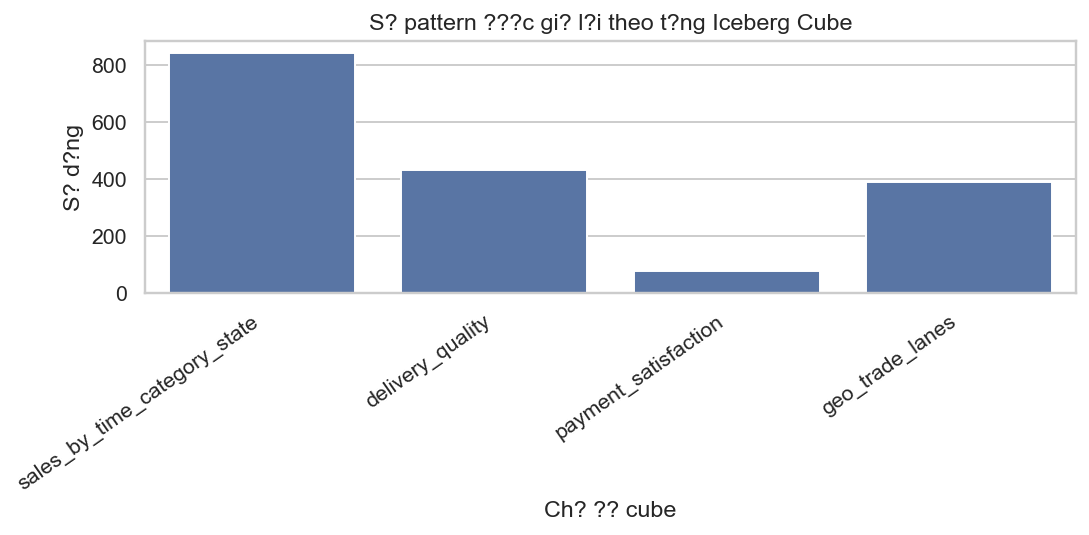

In [4]:
# Biểu đồ số pattern được giữ lại theo từng cube
cube_shapes

In [5]:
cubes['delivery_quality'].sort_values(['bad_review_rate', 'count_orders'], ascending=False).head(20)

,cuboid,dimension_count,seller_state,product_category_name_english,is_delayed,count_orders,sum_revenue,avg_review_score,avg_delivery_days,delay_rate,bad_review_rate
13,seller_state,1,unknown,ALL,ALL,775,0.00,1.721561,NaN,0.0,0.854701
189,seller_state x product_category_name_english,2,unknown,unknown,ALL,775,0.00,1.721561,NaN,0.0,0.854701
210,seller_state x is_delayed,2,unknown,ALL,0,775,0.00,1.721561,NaN,0.0,0.854701
431,seller_state x product_category_name_english x is_delayed,3,unknown,unknown,0,775,0.00,1.721561,NaN,0.0,0.854701
267,product_category_name_english x is_delayed,2,ALL,musical_instruments,1,54,18181.68,2.185185,33.616264,1.0,0.702128
426,seller_state x product_category_name_english x is_delayed,3,SP,toys,1,206,21035.95,2.292500,31.299723,1.0,0.686813
428,seller_state x product_category_name_english x is_delayed,3,SP,unknown,1,100,14625.24,2.340206,31.799893,1.0,0.686047
218,product_category_name_english x is_delayed,2,ALL,baby,1,258,41963.73,2.334661,32.821038,1.0,0.683258
430,seller_state x product_category_name_english x is_delayed,3,SP,watches_gifts,1,402,85885.89,2.389313,31.322311,1.0,0.672673
201,seller_state x is_delayed,2,PR,ALL,1,485,90195.81,2.365466,36.559176,1.0,0.668258


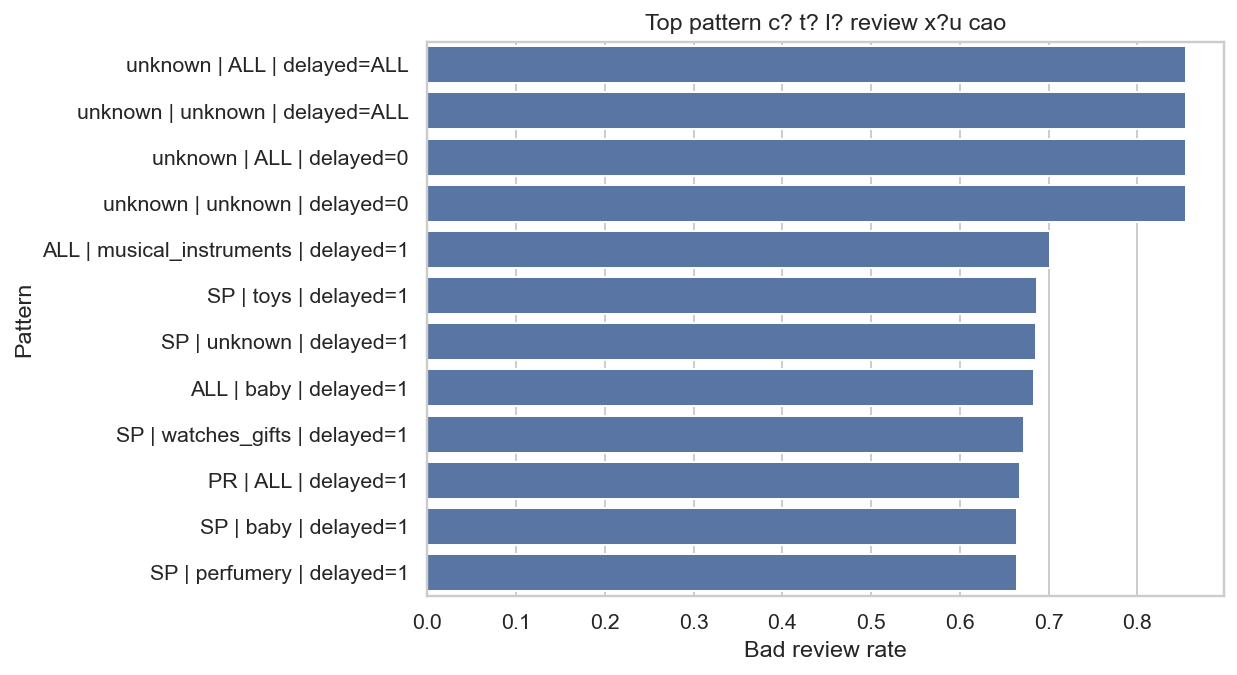

In [6]:
# Biểu đồ top pattern có tỷ lệ review xấu cao
delivery_top.head(12)